In [25]:
import importlib
import eval_functions
importlib.reload(eval_functions)
from eval_functions import *
import pandas as pd
from enum import Enum
import numpy as n

from IPython.display import display
# make tables interactive
from itables import init_notebook_mode
import itables.options as opt
init_notebook_mode(all_interactive=True, connected=True)
opt.maxBytes=0

In [26]:
KOFOLA_FAST="kofola-fast-012f094"
OLD_KOFOLA="kofola-fast-4cc321b"
SPOT="spot-2.14.1"

# Timeout (in seconds) 
TIMEOUT=120


TOOLS = list(dict.fromkeys([ # small hack so that we get list of unique values (i.e. a set, but also in the given order; see https://stackoverflow.com/questions/1653970/does-python-have-an-ordered-set)
    KOFOLA_FAST,
    SPOT,
    OLD_KOFOLA,

    # you can add more tools here directly if needed
]))

BENCHES = [
  "autohyper",
  "rabit",
  "termination",
]

In [27]:
df_all = load_benches_incl(BENCHES, TOOLS, TIMEOUT) # last parameter is timeout


## Evaluation

In [28]:

print(simple_table_incl(df_all, TOOLS, BENCHES, separately=False))
print(simple_table_incl(df_all, TOOLS, BENCHES, separately=True))

# of automata: 906
----------------------------------------------------------------------------------------------------
tool                   ✅    ❌    time    time-avg    time-med    TO    ERR
-------------------  ----  ----  ------  ----------  ----------  ----  -----
kofola-fast-012f094   906     0   96.90        0.11        0.00     0      0
spot-2.14.1           889    17   84.93        0.10        0.00     2     15
kofola-fast-4cc321b   905     1  425.35        0.47        0.00     1      0
----------------------------------------------------------------------------------------------------


Benchmark autohyper
# of automata: 72
----------------------------------------------------------------------------------------------------
tool                   ✅    ❌    time    time-avg    time-med    TO    ERR
-------------------  ----  ----  ------  ----------  ----------  ----  -----
kofola-fast-012f094    72     0    7.74        0.11        0.01     0      0
spot-2.14.1            68 

In [29]:
TOOL_FOR_COMPARISON = KOFOLA_FAST

### Time

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


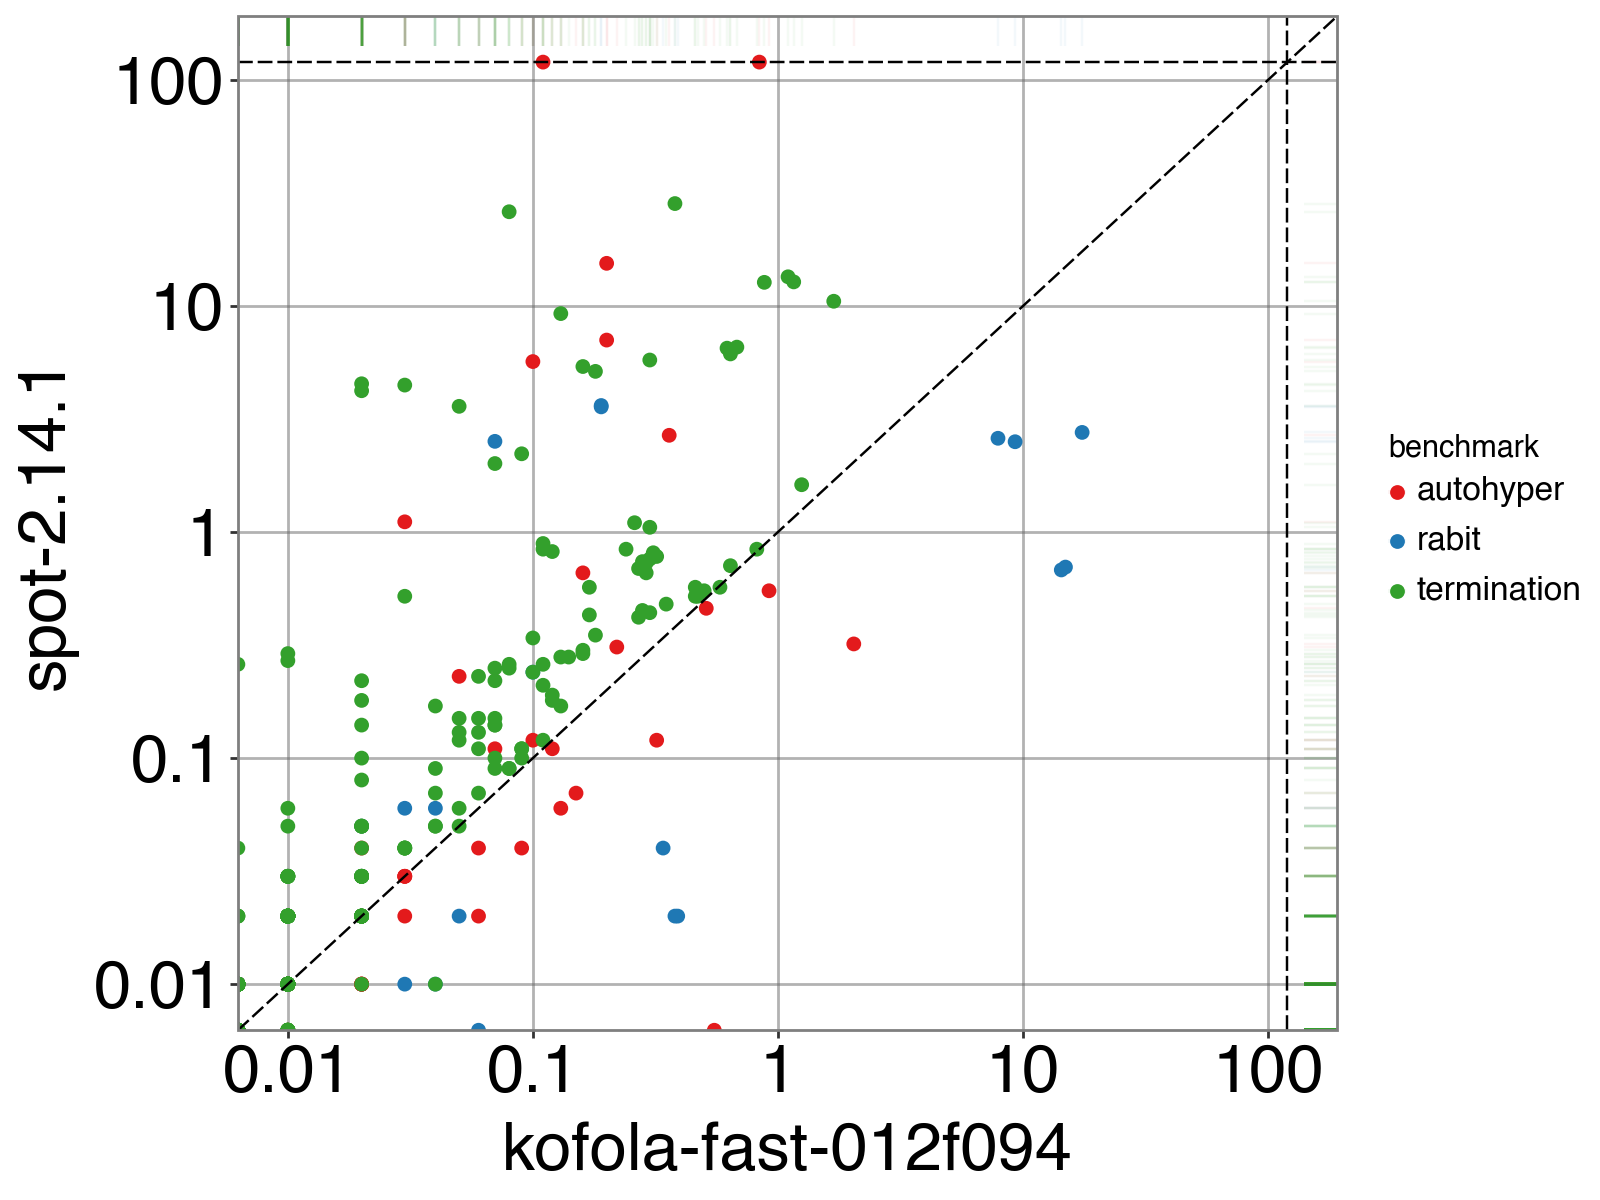

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


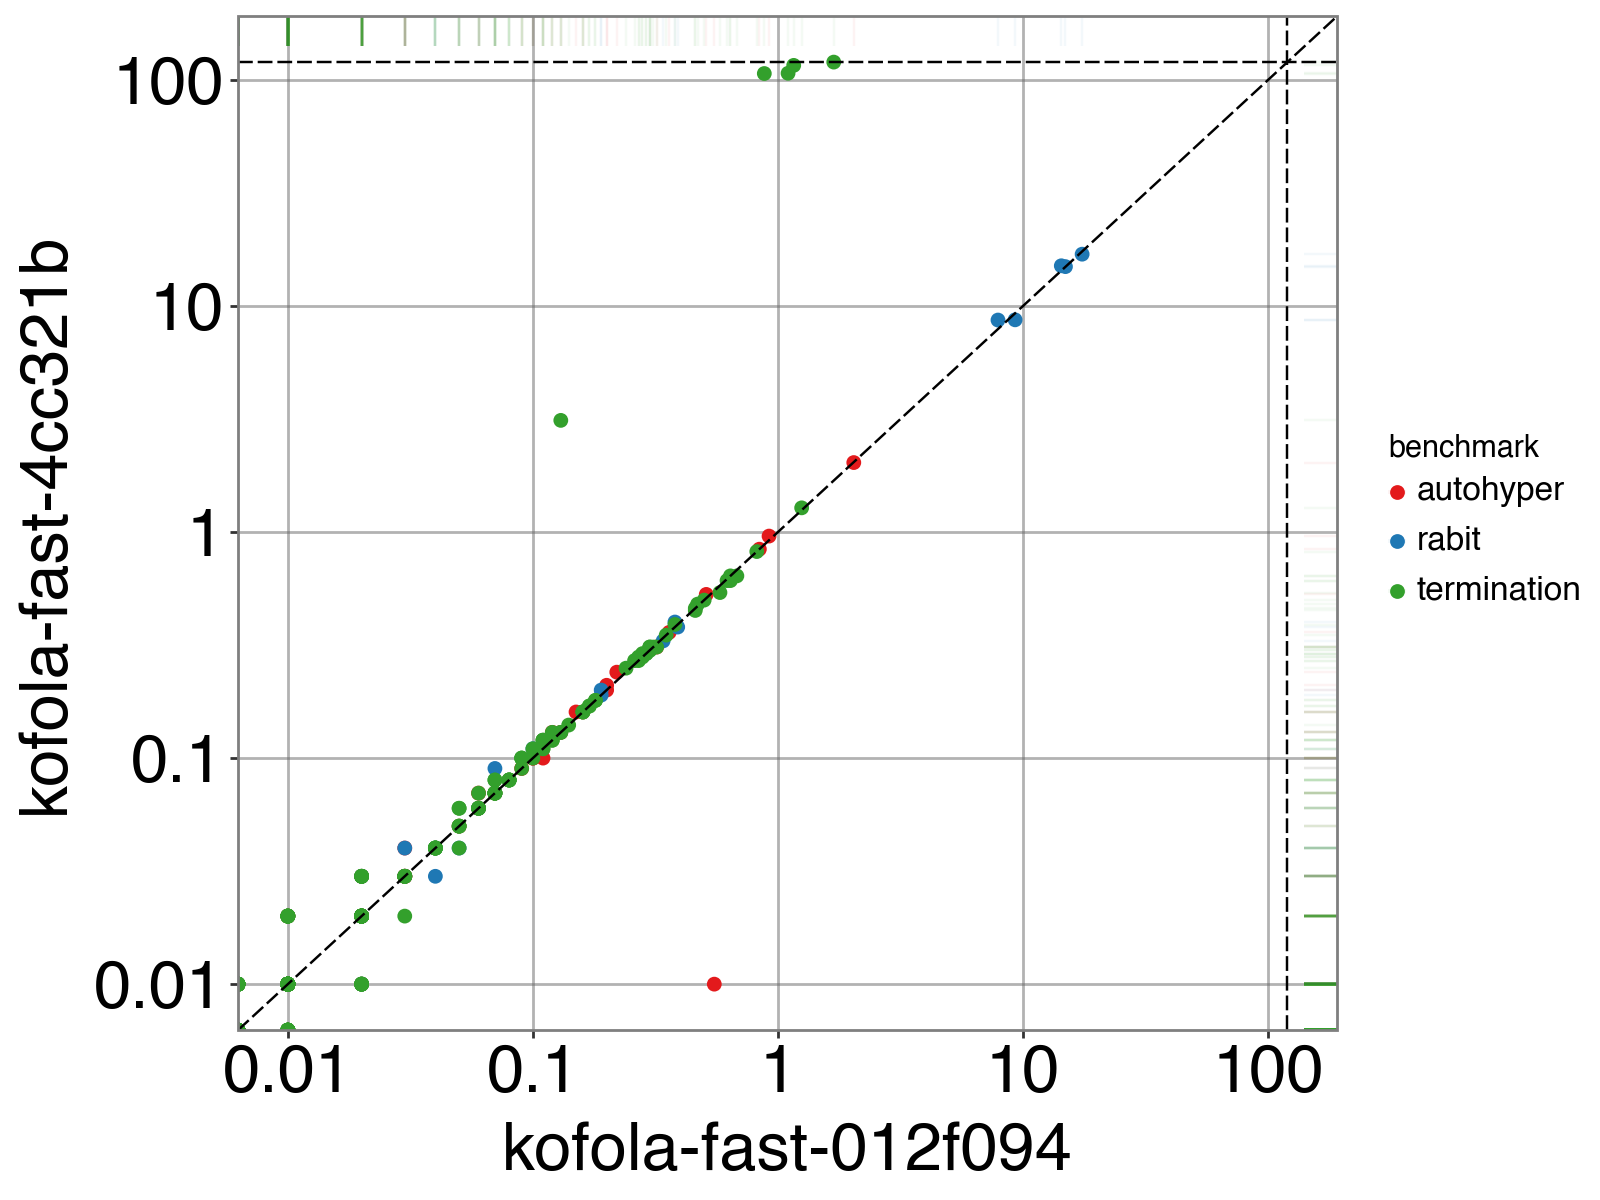

In [30]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", timeout=TIMEOUT, legend_name_map={"advanced_automata_termination":"termination"}))

### More detailed evaluation

In [31]:
sanity_check(df_all, TOOL_FOR_COMPARISON, [tool for tool in TOOLS if tool!=TOOL_FOR_COMPARISON])

Loading ITables v2.4.4 from the internet... (need help?)


In [32]:
get_errors_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [33]:
get_solved_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [10]:
get_timeouts_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)
